# HMM-mixed MVO

Supervised HMM on the A001 train slice (2001-01-01 through 2014-01-03). Test (2014-01-06 to 2022-08-31) is used for a four-line regime plot and a non-overlapping mean-variance backtest.

This notebook is the A001 counterpart of `hmm-mixed-mvo-ew.ipynb`. Regime labels, HMM emissions, and specialist pools come from `HMM-Diffusion.ipynb` (`configs/default.yaml`). There is no validation slice.

Mixing is **row-append** by **overall synth share** of the MVO training matrix: `synth_rows / (real_rows + synth_rows)`. The real lookback stays 252 days × 10 assets. Extra synth days are chosen so that share is 0%, 10%, …, 90%. Markowitz stays on the original 10 assets.

- `0%`: `252 × 10` (real lookback only).
- `10%`: `280 × 10` (28 synth days).
- `20%`: `315 × 10` (63 synth days).
- `90%`: `2520 × 10` (2268 synth days).

- **hmm-diffusion**: synth days from the specialist pool for predicted regime `k*`. `k*` is the **window average argmax** of the open-loop daily labels on that hold.
- **uncondi-diffusion**: synth days from `trained_diffusion_withoutregime/generated_data.csv`.

On each hold the regime forecast uses the transition matrix only. Emissions on that hold are applied after scoring, and only on those 63 days.

Run scripts 01–04 first so regime labels and specialist pools exist. Markowitz is sum-to-1 with shorts allowed; no max-weight cap in the default sweep.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config()
bootstrap_imports()

from hmmdiff import data, models, plots, pools, regimes
from hmmdiff.mvo import (
    load_specialist_pools,
    load_uncond_windows,
    run_mvo_backtest,
    run_scale_check,
    synth_rows_for_share,
    walk_open_loop,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

HORIZON = 63
STEP = 63
LOOKBACK = 252
MIX_MODE = "row"
MIX_GRID = list(range(0, 91, 10))
RANDOM_STATE = 42
N_REGIMES = int(cfg["regimes"]["n_regimes"])
TOP_K = int(cfg["hmm"]["top_k"])
ASSET_COLS = list(cfg["data"]["asset_columns"])
UNCOND_CSV = REPO_ROOT / "trained_diffusion_withoutregime" / "generated_data.csv"

print(
    f"{N_REGIMES} regimes, lookback {LOOKBACK}, hold {HORIZON}, step {STEP}, "
    f"mix {MIX_MODE}, synth share {MIX_GRID[0]}..{MIX_GRID[-1]}%"
)

5 regimes, lookback 252, hold 63, step 63, mix row, synth share 0..90%


## Setup


In [2]:
returns = data.load_returns(cfg)
counts = data.split_counts(returns)
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)

train_data, test_data = data.build_model_frames(returns, regime_labels, cfg)
_, test_regimes = data.split_labels(returns, regime_labels)

test_dates = pd.to_datetime(returns.loc[data.test_mask(returns), "date"])
train_dates = pd.to_datetime(returns.loc[data.train_mask(returns), "date"])

log_panel = data.build_multivariate_log_returns(cfg)[ASSET_COLS]
simple_panel = np.expm1(log_panel)
simple_panel.index = pd.to_datetime(simple_panel.index)

pools_root = config_path(cfg, "pools")
if not pools.pools_available(pools_root, N_REGIMES):
    raise FileNotFoundError(
        f"Specialist pools not found under {pools_root}. Run scripts 03 and 04."
    )
specialist_pools = load_specialist_pools(pools_root, N_REGIMES)
uncond_windows = load_uncond_windows(UNCOND_CSV)

print(f"returns      {counts['n_returns']:>6}  {counts['start_date']} to {counts['end_date']}")
print(f"train        {counts['n_train']:>6}  {train_dates.iloc[0].date()} to {train_dates.iloc[-1].date()}")
print(f"test         {counts['n_test']:>6}  {test_dates.iloc[0].date()} to {test_dates.iloc[-1].date()}")
print(f"10-asset panel {len(simple_panel):>5}  {simple_panel.index[0].date()} to {simple_panel.index[-1].date()}")
print(f"uncond windows {uncond_windows.shape}")
print(f"specialist pools {[specialist_pools[k].shape for k in range(N_REGIMES)]}")

assert str(test_dates.iloc[0].date()) == "2014-01-06"
assert str(test_dates.iloc[-1].date()) == "2022-08-31"
assert counts["n_train"] == cfg["reference"]["n_train"]
assert counts["n_test"] == cfg["reference"]["n_test"]
assert len(test_regimes) == len(test_dates)


returns        5653  2001-01-01 to 2022-08-31
train          3395  2001-01-01 to 2014-01-03
test           2258  2014-01-06 to 2022-08-31
10-asset panel  5653  2001-01-01 to 2022-08-31
uncond windows (1024, 128, 10)
specialist pools [(128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10)]


## Fit supervised HMM


In [3]:
init_dist = models.initial_distribution(train_data, N_REGIMES)
supervised = models.fit_supervised_hmm(train_data, N_REGIMES, cfg)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")
print("Posterior transition matrix")
display(pd.DataFrame(supervised.transmat.round(3), index=index, columns=columns))
print("Emission parameters")
display(supervised.summary())
print("Initial distribution (inner-train frequencies)")
display(pd.Series(init_dist, index=range(N_REGIMES), name="pi0"))

sample: 100%|██████████| 300/300 [00:06<00:00, 48.53it/s, 15 steps of size 2.18e-01. acc. prob=0.82] 


Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0010,0.0010,0.0000,0.0000
1,0.0030,0.9950,0.0000,0.0010,0.0010
2,0.0080,0.0080,0.9810,0.0010,0.0010
3,0.0010,0.0120,0.0010,0.9850,0.0010
4,0.0040,0.0020,0.0030,0.0160,0.9750


Emission parameters


,mean,sigma
regime,,
0,0.0274,0.5952
1,-0.0279,1.0411
2,-0.0236,1.6168
3,-0.0749,1.8916
4,-0.3899,3.6466


Initial distribution (inner-train frequencies)


0   0.5567
1   0.3299
2   0.0412
3   0.0515
4   0.0206
Name: pi0, dtype: float64

## Rolling open-loop forecast


In [4]:
walk = walk_open_loop(
    train_data.emission.values,
    test_data.emission.values,
    supervised.transmat,
    supervised.mu,
    supervised.sigma,
    init_dist,
    horizon=HORIZON,
    step=STEP,
)

print(f"holds {len(walk.hold_starts)}  first test day {test_dates.iloc[0].date()}")
print(
    "hmm-diffusion k* = window average argmax; "
    f"first hold k* {int(walk.hold_k_star[0])}  last hold k* {int(walk.hold_k_star[-1])}"
)
print(
    "open-loop days filled",
    int(np.isfinite(walk.daily_argmax).sum()),
    "of",
    len(test_regimes),
)


holds 35  first test day 2014-01-06
hmm-diffusion k* = window average argmax; first hold k* 0  last hold k* 1
open-loop days filled 2205 of 2258


## Regime plot and accuracy

Three comparisons versus clustering truth:

1. **Forward-backward** — daily argmax of smoothed regime probabilities (uses emissions). Compared with daily clustering labels.
2. **Daily argmax** — each day's argmax of the open-loop regime probability (transition matrix only). Compared with daily clustering labels.
3. **Window average argmax** — one occupancy label per 63-day hold, copied to every day in that hold. Compared with daily clustering labels. **hmm-diffusion MVO samples all `n` synth windows from this regime's pool.**


100%|██████████| 2258/2258 [00:00<00:00, 93160.00it/s]
2258it [00:00, 98148.47it/s]

Test does not contain regimes [2, 3]; accuracy uses observed labels.


,truth,accuracy
estimate,,
Forward-backward,daily clustering labels,0.7285
Daily argmax,daily clustering labels,0.6644
Window average argmax,daily clustering labels,0.6354


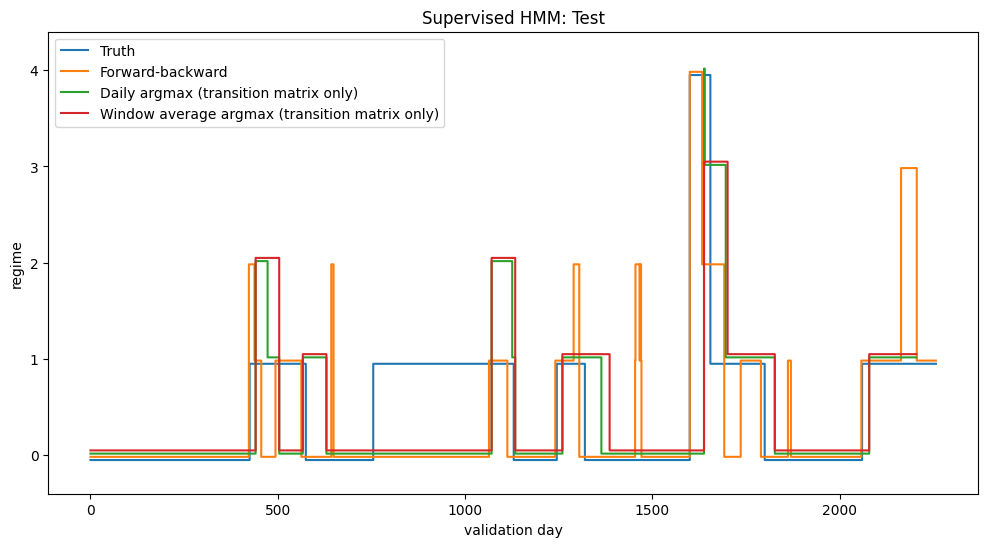

In [5]:
fb_probs, fb_est = models.estimate_states(
    supervised, test_data.emission.values, init_dist, N_REGIMES
)

present = sorted(set(test_regimes.tolist()))
missing = [k for k in range(N_REGIMES) if k not in present]
if missing:
    print(f"Test does not contain regimes {missing}; accuracy uses observed labels.")

fb_acc = models.accuracy_report(test_regimes, fb_est, fb_probs, N_REGIMES, TOP_K)

daily_mask = np.isfinite(walk.daily_argmax)
daily_est = walk.daily_argmax[daily_mask].astype(int)
daily_truth = test_regimes[daily_mask]
daily_score = walk.open_loop_pi[daily_mask]
daily_acc = models.accuracy_report(daily_truth, daily_est, daily_score, N_REGIMES, TOP_K)

window_daily_score = np.full((len(test_regimes), N_REGIMES), np.nan)
for start in walk.hold_starts:
    sl = slice(int(start), int(start) + HORIZON)
    est_states = walk.daily_argmax[sl].astype(int)
    est_avg = np.eye(N_REGIMES)[est_states].mean(axis=0)
    window_daily_score[sl] = est_avg
window_daily_est = walk.window_argmax[daily_mask].astype(int)
window_daily_acc = models.accuracy_report(
    daily_truth, window_daily_est, window_daily_score[daily_mask], N_REGIMES, TOP_K
)

acc_table = pd.DataFrame(
    [
        {
            "estimate": "Forward-backward",
            "truth": "daily clustering labels",
            **fb_acc,
        },
        {
            "estimate": "Daily argmax",
            "truth": "daily clustering labels",
            **daily_acc,
        },
        {
            "estimate": "Window average argmax",
            "truth": "daily clustering labels",
            **window_daily_acc,
        },
    ]
).set_index("estimate")
display(acc_table[["truth", "accuracy"]])

plots.plot_regime_paths(
    {
        "Truth": test_regimes,
        "Forward-backward": fb_est,
        "Daily argmax (transition matrix only)": walk.daily_argmax,
        "Window average argmax (transition matrix only)": walk.window_argmax,
    },
    "Supervised HMM: Test",
    jiggle=0.05,
)


## Scale check


In [6]:
first_hold_date = test_dates.iloc[int(walk.hold_starts[0])]
prior = simple_panel.loc[simple_panel.index < first_hold_date]
lookback_start = prior.index[-LOOKBACK]
real_ref = np.log1p(simple_panel.loc[lookback_start:test_dates.iloc[-1], ASSET_COLS].to_numpy())

scale = run_scale_check(real_ref, specialist_pools, uncond_windows, ASSET_COLS)
display(scale.table)
if not scale.ok:
    for line in scale.messages:
        print(f"[FAIL] {line}")
    raise SystemExit("Scale check failed; synth units do not match real MVO inputs.")
print("[OK] native log-return scale; simple-return std within 0.1×–10× of real")


,source,asset,native_std,simple_mean,simple_std,simple_min,simple_max,simple_p01,simple_p99
0,real,A001,0.0108,0.0005,0.0107,-0.1198,0.0939,-0.0323,0.0249
1,real,A004,0.0024,0.0001,0.0024,-0.0207,0.0108,-0.0062,0.0056
2,real,A006,0.0006,0.0000,0.0006,-0.0053,0.0039,-0.0018,0.0020
3,real,A008,0.0031,0.0002,0.0030,-0.0312,0.0308,-0.0092,0.0078
4,real,A009,0.0039,0.0001,0.0038,-0.0504,0.0357,-0.0096,0.0093
5,real,A011,0.0114,0.0005,0.0114,-0.1321,0.1082,-0.0306,0.0265
6,real,A012,0.0137,0.0004,0.0136,-0.1421,0.0940,-0.0358,0.0312
7,real,A013,0.0090,0.0002,0.0089,-0.1036,0.0716,-0.0252,0.0217
8,real,A014,0.0098,0.0001,0.0098,-0.0670,0.0574,-0.0266,0.0236
9,real,A015,0.0128,0.0003,0.0127,-0.1885,0.0905,-0.0329,0.0285


[OK] native log-return scale; simple-return std within 0.1×–10× of real


## MVO config

Lookback, hold, and step are trading-day counts. Later cells keep these windows and only change objective or constraints. Holds start on 2014-01-06 and stay inside the test slice through 2022-08-31. Mixing is row-append: the training matrix stays 10 columns and grows in rows.


In [7]:
from hmmdiff.mvo.backtest import lookback_and_hold, window_vol_bucket
from hmmdiff.mvo.portfolio_core import TRADING_DAYS, sharpe_ratio

n_assets = len(ASSET_COLS)
mvo_config = pd.DataFrame(
    [
        ("lookback", LOOKBACK, "trading days for μ and Σ"),
        ("hold / horizon", HORIZON, "days the weights are held"),
        ("step", STEP, "days between consecutive hold starts"),
        ("non-overlapping", STEP == HORIZON, "step equals hold"),
        ("mix grid", f"{MIX_GRID[0]}–{MIX_GRID[-1]}%", "synth share of the training matrix"),
        ("n assets", n_assets, ", ".join(ASSET_COLS)),
        ("random state", RANDOM_STATE, "seed + hold_start + n_synth"),
        ("ridge", 1e-6, "covariance diagonal; raised if T ≤ n_feat"),
        ("k*", "window average argmax", "hmm-diffusion specialist pool"),
        ("mix mode", MIX_MODE, "row-append synth under the real lookback"),
        ("default objective", "mean-variance", "later cells override"),
        ("default constraints", "unconstrained", "shorts allowed, no name cap"),
        ("synth window length", int(uncond_windows.shape[1]), "must be ≥ hold"),
        ("uncond pool size", int(uncond_windows.shape[0]), "regime-free CSV"),
        (
            "specialist pool size",
            int(next(iter(specialist_pools.values())).shape[0]),
            "windows per regime",
        ),
        ("train matrix 0%", f"{LOOKBACK} × {n_assets}", "real lookback only"),
        (
            f"train matrix {MIX_GRID[-1]}%",
            f"{LOOKBACK + synth_rows_for_share(LOOKBACK, MIX_GRID[-1] / 100.0)} × {n_assets}",
            "real plus row-appended synth",
        ),
    ],
    columns=["parameter", "value", "note"],
)
display(mvo_config)

hold_rows = []
for i, start in enumerate(walk.hold_starts.tolist()):
    start = int(start)
    sliced = lookback_and_hold(
        simple_panel[ASSET_COLS], test_dates.to_numpy(), start, LOOKBACK, HORIZON
    )
    hold_labels = test_regimes[start : start + HORIZON]
    hold_rows.append(
        {
            "hold": i,
            "start": test_dates.iloc[start].date(),
            "end": test_dates.iloc[start + HORIZON - 1].date(),
            "complete": sliced is not None,
            "bucket": window_vol_bucket(hold_labels),
            "k_star": int(walk.hold_k_star[i]),
        }
    )
holds = pd.DataFrame(hold_rows)
print(
    f"holds scheduled {len(holds)}  complete {int(holds['complete'].sum())}  "
    f"skipped {int((~holds['complete']).sum())}  "
    f"first {holds['start'].iloc[0]}  last start {holds['start'].iloc[-1]}"
)
display(holds["bucket"].value_counts().rename_axis("bucket").to_frame("n_holds"))
display(holds["k_star"].value_counts().sort_index().rename_axis("k*").to_frame("n_holds"))

test_simple = simple_panel.reindex(pd.DatetimeIndex(test_dates))[ASSET_COLS]
ann_mu = test_simple.mean() * TRADING_DAYS
ann_sd = test_simple.std(ddof=0) * np.sqrt(TRADING_DAYS)
asset_stats = pd.DataFrame({"ann_mu": ann_mu, "ann_sd": ann_sd, "sharpe": ann_mu / ann_sd})
pair_corr = test_simple.corr().to_numpy()
mean_pair_corr = float(pair_corr[np.triu_indices_from(pair_corr, k=1)].mean())
ew = test_simple.mean(axis=1).to_numpy()
print(
    f"test panel {test_simple.dropna(how='any').shape[0]} days  "
    f"mean pairwise corr {mean_pair_corr:.3f}  "
    f"equal-weight Sharpe {sharpe_ratio(ew):.3f}"
)
display(asset_stats.T)


,parameter,value,note
0,lookback,252,trading days for μ and Σ
1,hold / horizon,63,days the weights are held
2,step,63,days between consecutive hold starts
3,non-overlapping,True,step equals hold
4,mix grid,0–90%,synth share of the training matrix
5,n assets,10,"A001, A004, A006, A008, A009, A011, A012, A013..."
6,random state,42,seed + hold_start + n_synth
7,ridge,0.0000,covariance diagonal; raised if T ≤ n_feat
8,k*,window average argmax,hmm-diffusion specialist pool
9,mix mode,row,row-append synth under the real lookback


holds scheduled 35  complete 35  skipped 0  first 2014-01-06  last start 2022-03-23


,n_holds
bucket,
low vol,34
high vol,1


,n_holds
k*,
0,25
1,7
2,2
3,1


test panel 2258 days  mean pairwise corr 0.373  equal-weight Sharpe 0.576


,A001,A004,A006,A008,A009,A011,A012,A013,A014,A015
ann_mu,0.1199,0.0175,0.0093,0.0371,0.0233,0.1022,0.0898,0.0325,0.0375,0.0958
ann_sd,0.1756,0.0378,0.0103,0.0500,0.0604,0.1858,0.2220,0.1435,0.1575,0.2053
sharpe,0.6829,0.4636,0.9030,0.7421,0.3858,0.5498,0.4044,0.2267,0.2380,0.4668


## MVO backtest

`MIX_GRID` is the synth **share of the whole training matrix**: `synth_rows / (252 + synth_rows)`. 0% is real lookback only. Plots show 0% through 90%.



In [8]:
result = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=True,
    mix_mode=MIX_MODE,
)

n0 = result.windows.loc[result.windows["n_synth"] == 0]
if n0.empty:
    raise SystemExit("No completed MVO holds.")
hmm_n0 = n0.loc[n0["method"] == "hmm-diffusion", ["hold_start", "sharpe", "calmar"]]
uncond_n0 = n0.loc[n0["method"] == "uncondi-diffusion", ["hold_start", "sharpe", "calmar"]]
merged = hmm_n0.merge(uncond_n0, on="hold_start", suffixes=("_hmm", "_uncond"))
sharpe_gap = float(np.nanmax(np.abs(merged["sharpe_hmm"] - merged["sharpe_uncond"])))
calmar_gap = float(np.nanmax(np.abs(merged["calmar_hmm"] - merged["calmar_uncond"])))
print(f"holds scored {merged.shape[0]}  n=0 max |Δ Sharpe| {sharpe_gap:.6g}  |Δ Calmar| {calmar_gap:.6g}")
if sharpe_gap > 1e-10 or calmar_gap > 1e-10:
    raise SystemExit("n=0 hmm-diffusion and uncondi-diffusion should match.")

print("bucket counts at n=0")
display(n0.loc[n0["method"] == "hmm-diffusion", "bucket"].value_counts())
print(f"first hold {result.windows['start_date'].min().date()}  last hold start {result.windows['start_date'].max().date()}")
assert str(result.windows["start_date"].min().date()) == "2014-01-06"


holds scored 35  n=0 max |Δ Sharpe| 0  |Δ Calmar| 0
bucket counts at n=0


bucket
low vol     34
high vol     1
Name: count, dtype: int64

first hold 2014-01-06  last hold start 2022-03-23


## Sharpe and Calmar

The x-axis is **% of synth in the training matrix**: `synth_rows / (real_rows + synth_rows)`. Ticks are 0, 10, 20, …, 90. 0% is all real lookback.


Row-append mix: % of synth is synth_rows / (real_rows + synth_rows). Real lookback stays 252 × 10. 10% adds 28 days; 20% adds 63 days; 90% adds 2268 days.


,synth_pct,real_rows,real_cols,synth_rows,train_rows,train_matrix,synth_row_share
0,0,252,10,0,252,252 × 10,0.0000
1,10,252,10,28,280,280 × 10,0.1000
2,20,252,10,63,315,315 × 10,0.2000
3,30,252,10,108,360,360 × 10,0.3000
4,40,252,10,168,420,420 × 10,0.4000
5,50,252,10,252,504,504 × 10,0.5000
6,60,252,10,378,630,630 × 10,0.6000
7,70,252,10,588,840,840 × 10,0.7000
8,80,252,10,1008,1260,1260 × 10,0.8000
9,90,252,10,2268,2520,2520 × 10,0.9000


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,1,-0.5453,-0.5453,-6.0300,-6.0300,-6.0477,-6.0477,122.9901,122.9901
20,uncondi-diffusion,0,0.0000,high vol,1,-0.5453,-0.5453,-6.0300,-6.0300,-6.0477,-6.0477,122.9901,122.9901
2,hmm-diffusion,10,10.0000,high vol,1,-1.1596,-1.1596,-15.6109,-15.6109,-18.5549,-18.5549,256.0191,256.0191
22,uncondi-diffusion,10,10.0000,high vol,1,-1.7243,-1.7243,-22.9351,-22.9351,-30.0550,-30.0550,303.8170,303.8170
4,hmm-diffusion,20,20.0000,high vol,1,-0.7538,-0.7538,-10.0027,-10.0027,-13.4502,-13.4502,318.3504,318.3504
24,uncondi-diffusion,20,20.0000,high vol,1,-2.0199,-2.0199,-34.9378,-34.9378,-35.3725,-35.3725,306.6751,306.6751
6,hmm-diffusion,30,30.0000,high vol,1,-1.9467,-1.9467,-1.6101,-1.6101,-44.2018,-44.2018,515.5532,515.5532
26,uncondi-diffusion,30,30.0000,high vol,1,-1.8185,-1.8185,-8.5203,-8.5203,-38.5673,-38.5673,449.7807,449.7807
8,hmm-diffusion,40,40.0000,high vol,1,-2.2326,-2.2326,-49.8183,-49.8183,-54.8427,-54.8427,603.4342,603.4342
28,uncondi-diffusion,40,40.0000,high vol,1,-2.4210,-2.4210,-1.8646,-1.8646,-70.3539,-70.3539,844.4924,844.4924


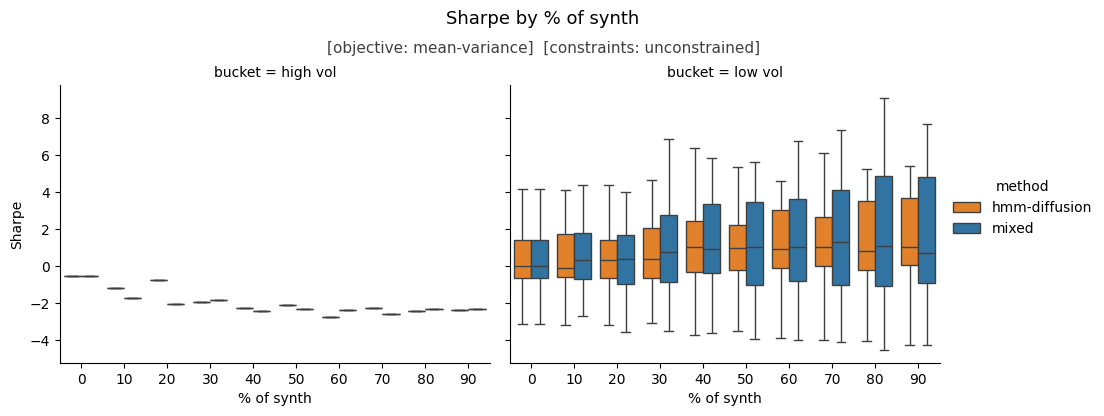

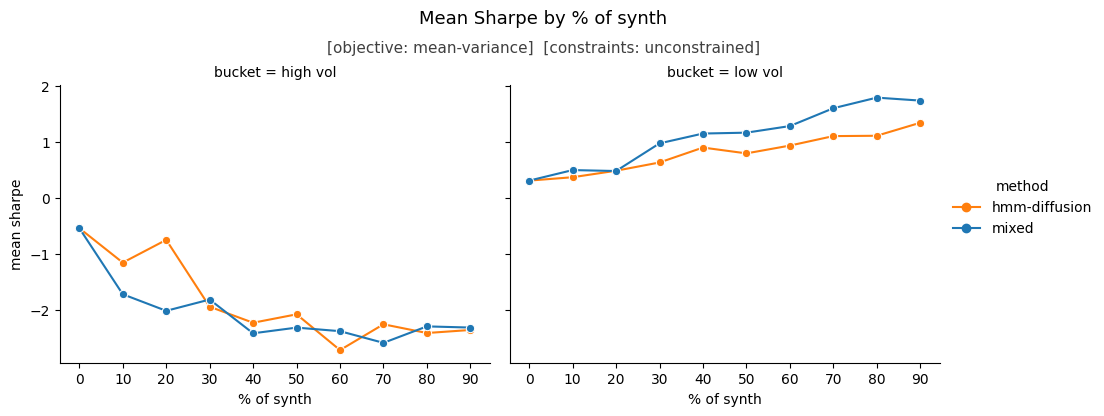

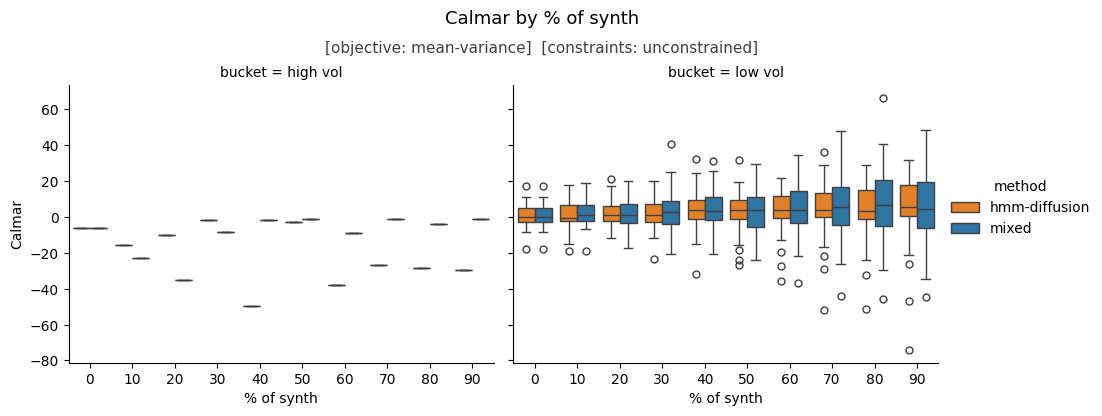

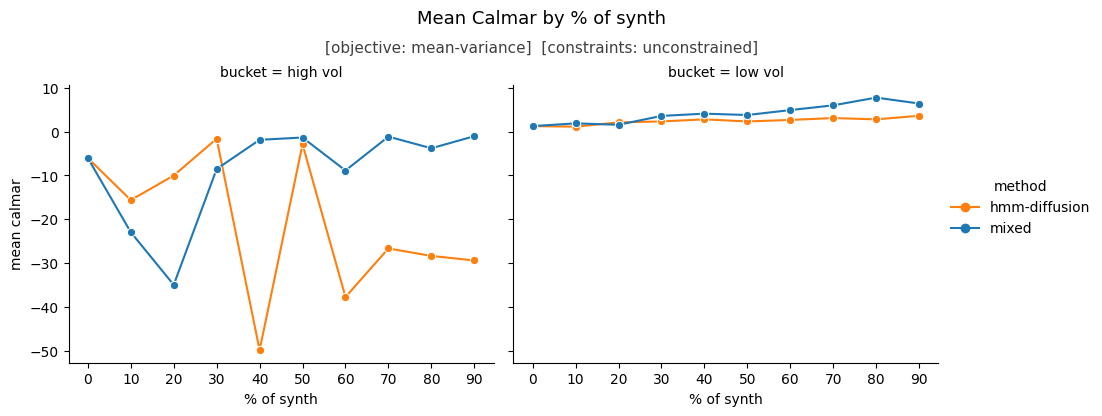

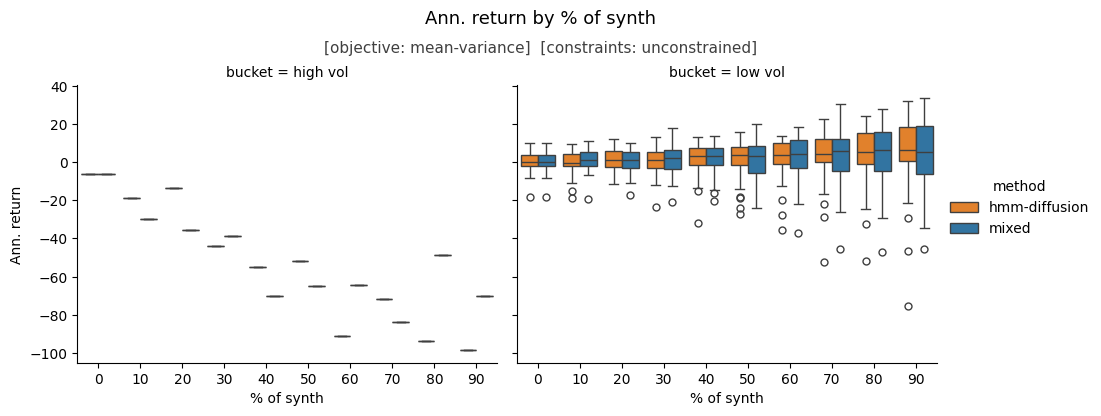

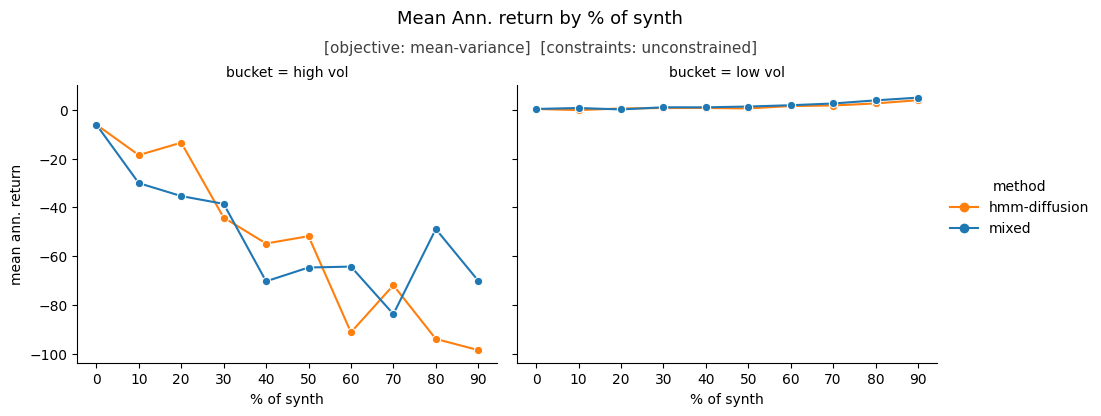

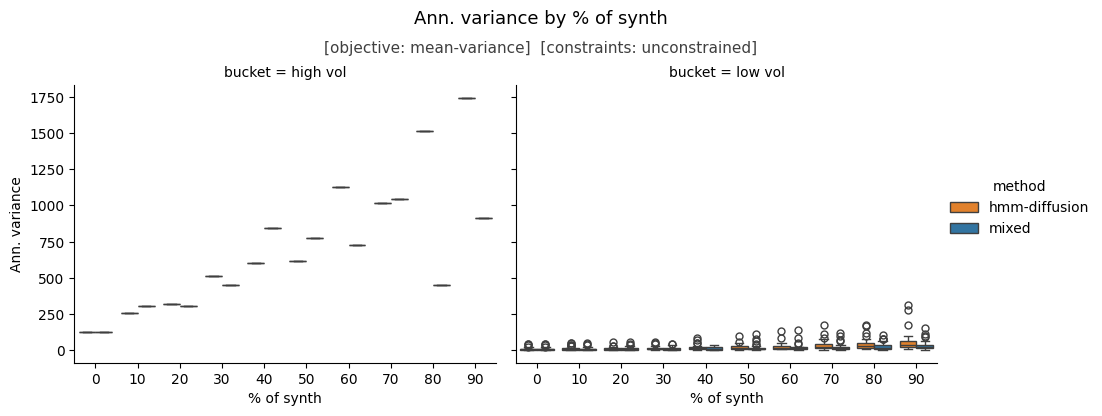

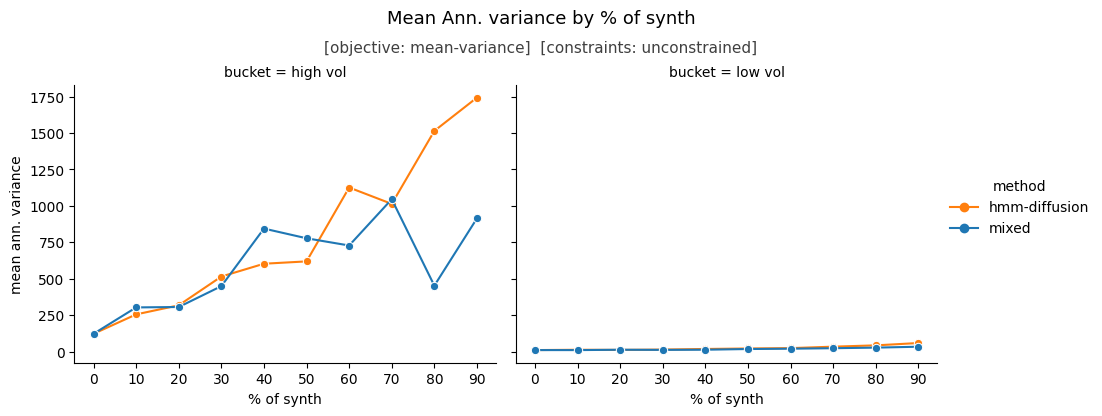

In [9]:
n_assets = len(ASSET_COLS)
synth_rows = [synth_rows_for_share(LOOKBACK, p / 100.0) for p in MIX_GRID]
mix_size = pd.DataFrame(
    {
        "synth_pct": MIX_GRID,
        "real_rows": LOOKBACK,
        "real_cols": n_assets,
        "synth_rows": synth_rows,
        "train_rows": [LOOKBACK + r for r in synth_rows],
        "train_matrix": [f"{LOOKBACK + r} × {n_assets}" for r in synth_rows],
        "synth_row_share": [
            r / (LOOKBACK + r) if r else 0.0 for r in synth_rows
        ],
    }
)
print(
    "Row-append mix: % of synth is synth_rows / (real_rows + synth_rows). "
    "Real lookback stays 252 × 10. 10% adds 28 days; 20% adds 63 days; 90% adds 2268 days."
)
display(mix_size)

display(result.summary.sort_values(["bucket", "n_synth", "method"]))
for metric in plots.MVO_WINDOW_METRICS:
    plots.plot_mvo_boxes(
        result.windows, metric, objective="mean-variance", constraint="unconstrained"
    )
    plots.plot_mvo_means(
        result.windows, metric, objective="mean-variance", constraint="unconstrained"
    )

## Long-only MVO

Same mix, holds, and seeds as the unconstrained sweep. `allow_short=False` clips negative weights on the 10 assets, then renormalizes. This is clip-and-renorm, not a QP with `w ≥ 0`. `n=0` long-only will not match unconstrained `n=0`.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,1,-0.9270,-0.9270,-1.1442,-1.1442,-0.1876,-0.1876,0.0409,0.0409
20,uncondi-diffusion,0,0.0000,high vol,1,-0.9270,-0.9270,-1.1442,-1.1442,-0.1876,-0.1876,0.0409,0.0409
2,hmm-diffusion,10,10.0000,high vol,1,-1.2063,-1.2063,-1.4418,-1.4418,-0.2680,-0.2680,0.0494,0.0494
22,uncondi-diffusion,10,10.0000,high vol,1,-1.4923,-1.4923,-1.6658,-1.6658,-0.3052,-0.3052,0.0418,0.0418
4,hmm-diffusion,20,20.0000,high vol,1,-1.1881,-1.1881,-1.5963,-1.5963,-0.3444,-0.3444,0.0840,0.0840
24,uncondi-diffusion,20,20.0000,high vol,1,-1.5508,-1.5508,-1.5956,-1.5956,-0.2760,-0.2760,0.0317,0.0317
6,hmm-diffusion,30,30.0000,high vol,1,-1.5738,-1.5738,-1.7006,-1.7006,-0.3352,-0.3352,0.0454,0.0454
26,uncondi-diffusion,30,30.0000,high vol,1,-1.4891,-1.4891,-1.5063,-1.5063,-0.2441,-0.2441,0.0269,0.0269
8,hmm-diffusion,40,40.0000,high vol,1,-1.5343,-1.5343,-1.5380,-1.5380,-0.2278,-0.2278,0.0220,0.0220
28,uncondi-diffusion,40,40.0000,high vol,1,-1.7413,-1.7413,-1.6719,-1.6719,-0.2692,-0.2692,0.0239,0.0239


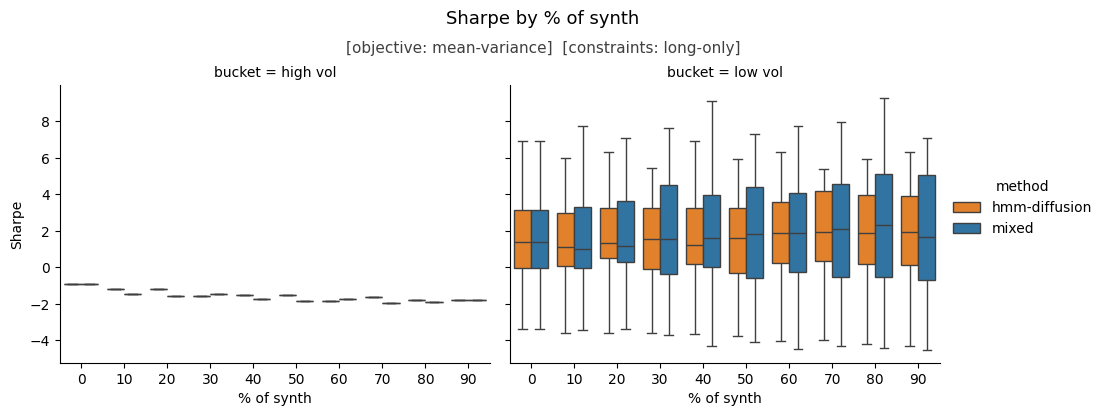

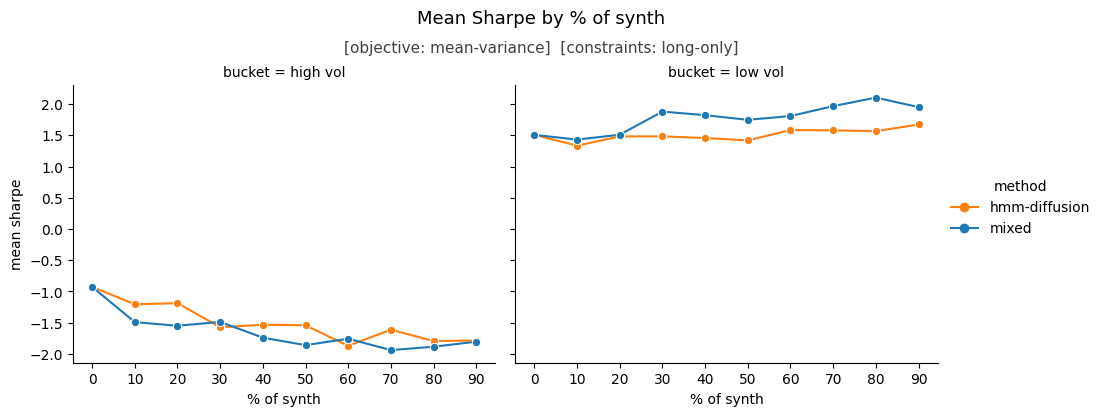

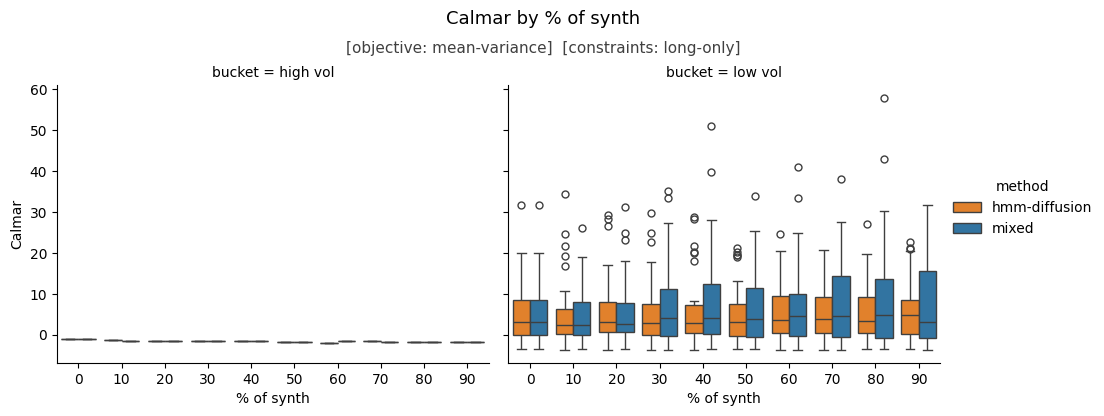

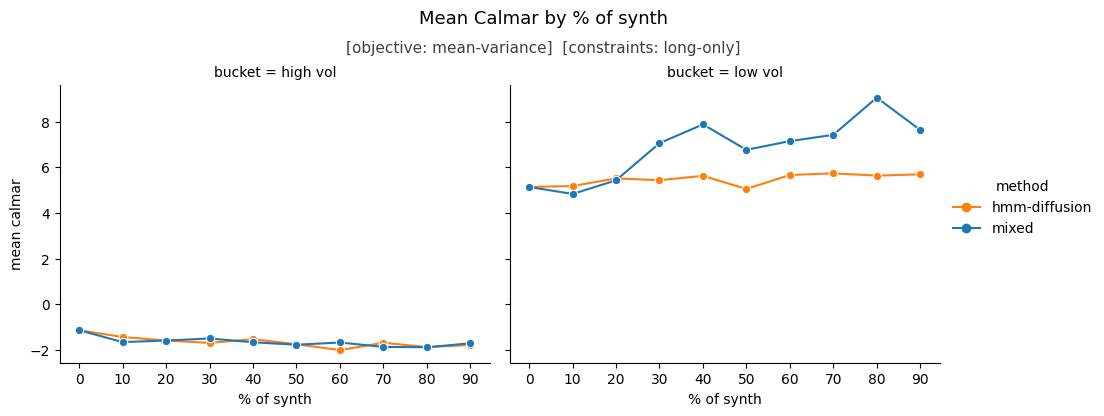

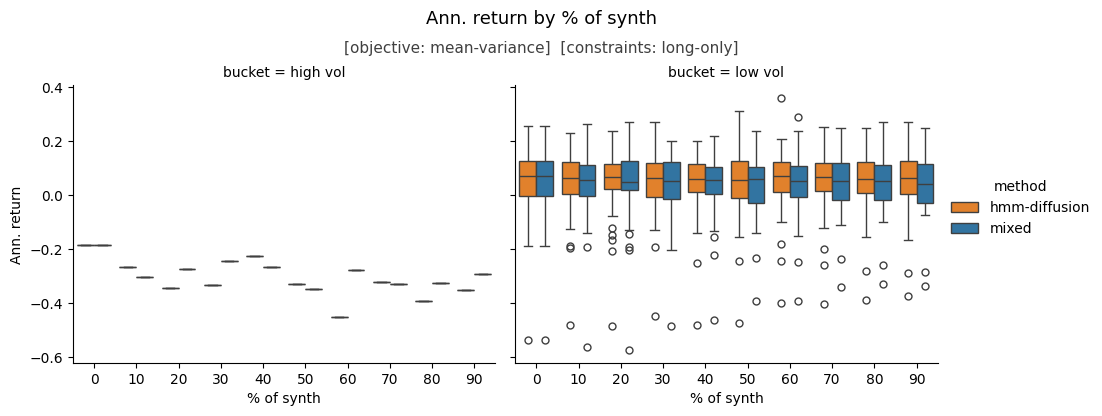

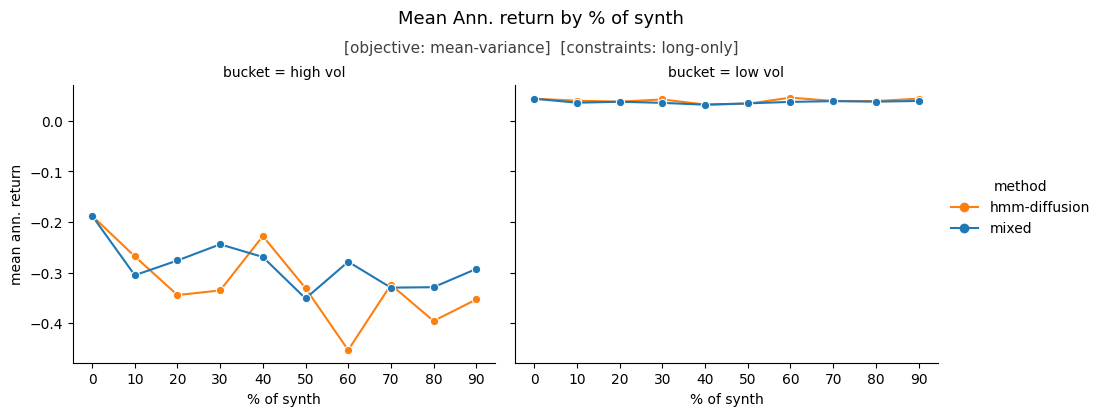

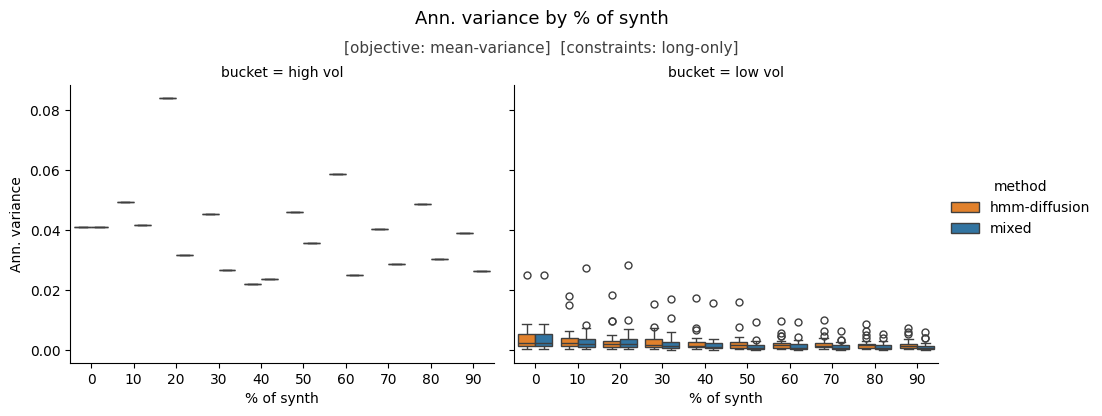

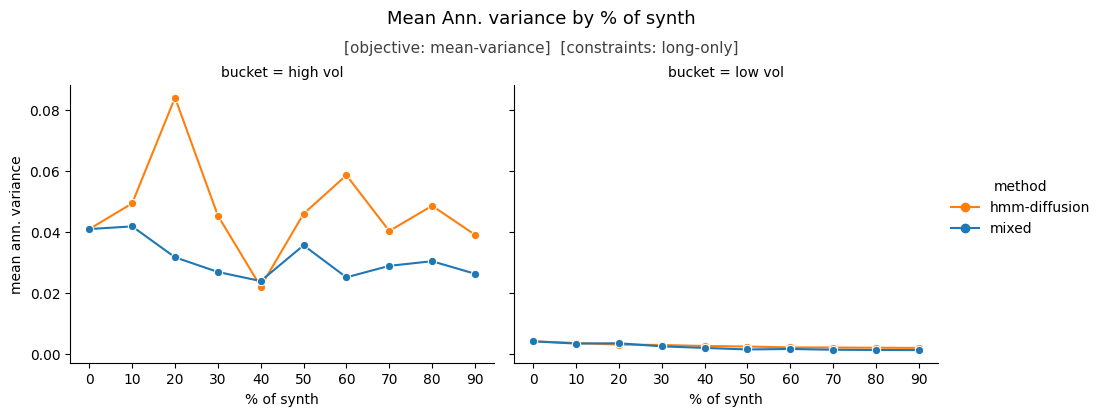

In [10]:
result_long_only = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    mix_mode=MIX_MODE,
)

display(result_long_only.summary.sort_values(["bucket", "n_synth", "method"]))
for metric in plots.MVO_WINDOW_METRICS:
    plots.plot_mvo_boxes(
        result_long_only.windows, metric, objective="mean-variance", constraint="long-only"
    )
    plots.plot_mvo_means(
        result_long_only.windows, metric, objective="mean-variance", constraint="long-only"
    )


## Long-only 30% cap

Same mix, holds, and seeds. After Markowitz, the 10 traded weights are projected onto `sum w = 1`, `w ≥ 0`, and `w ≤ 0.30`. That is a standard name cap: no asset can be more than 30% of the book.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,1,-1.1762,-1.1762,-1.4677,-1.4677,-0.2916,-0.2916,0.0615,0.0615
20,uncondi-diffusion,0,0.0000,high vol,1,-1.1762,-1.1762,-1.4677,-1.4677,-0.2916,-0.2916,0.0615,0.0615
2,hmm-diffusion,10,10.0000,high vol,1,-1.3049,-1.3049,-1.5751,-1.5751,-0.3192,-0.3192,0.0599,0.0599
22,uncondi-diffusion,10,10.0000,high vol,1,-1.6007,-1.6007,-1.8208,-1.8208,-0.3751,-0.3751,0.0549,0.0549
4,hmm-diffusion,20,20.0000,high vol,1,-1.2423,-1.2423,-1.6362,-1.6362,-0.3494,-0.3494,0.0791,0.0791
24,uncondi-diffusion,20,20.0000,high vol,1,-1.5508,-1.5508,-1.5956,-1.5956,-0.2760,-0.2760,0.0317,0.0317
6,hmm-diffusion,30,30.0000,high vol,1,-1.5951,-1.5951,-1.7317,-1.7317,-0.3491,-0.3491,0.0479,0.0479
26,uncondi-diffusion,30,30.0000,high vol,1,-1.6382,-1.6382,-1.7181,-1.7181,-0.3231,-0.3231,0.0389,0.0389
8,hmm-diffusion,40,40.0000,high vol,1,-1.8460,-1.8460,-1.9480,-1.9480,-0.3960,-0.3960,0.0460,0.0460
28,uncondi-diffusion,40,40.0000,high vol,1,-1.7553,-1.7553,-1.7077,-1.7077,-0.2799,-0.2799,0.0254,0.0254


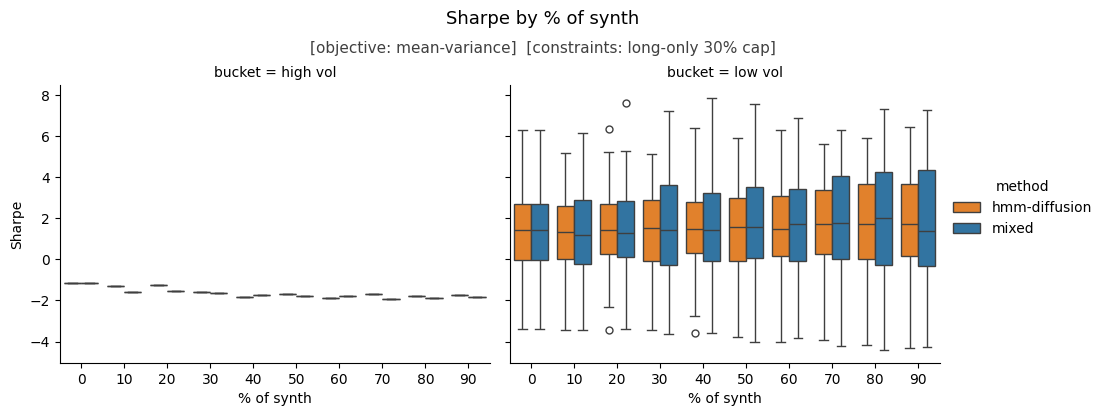

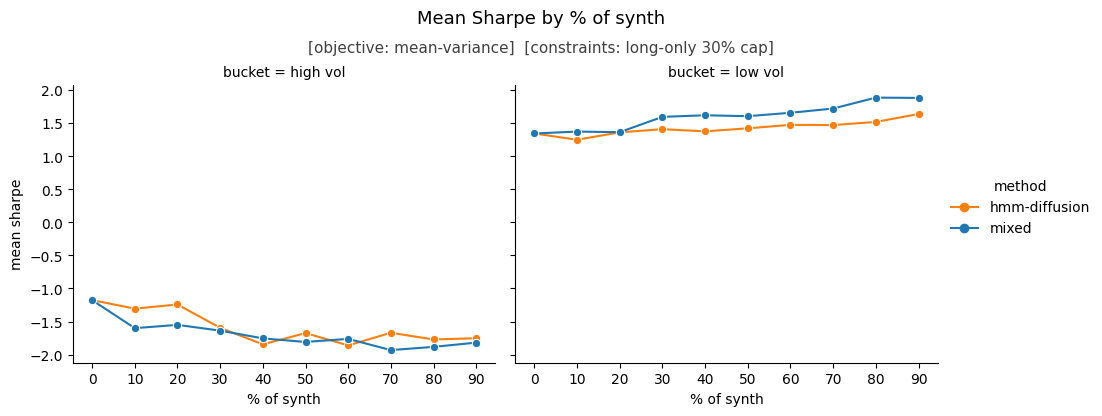

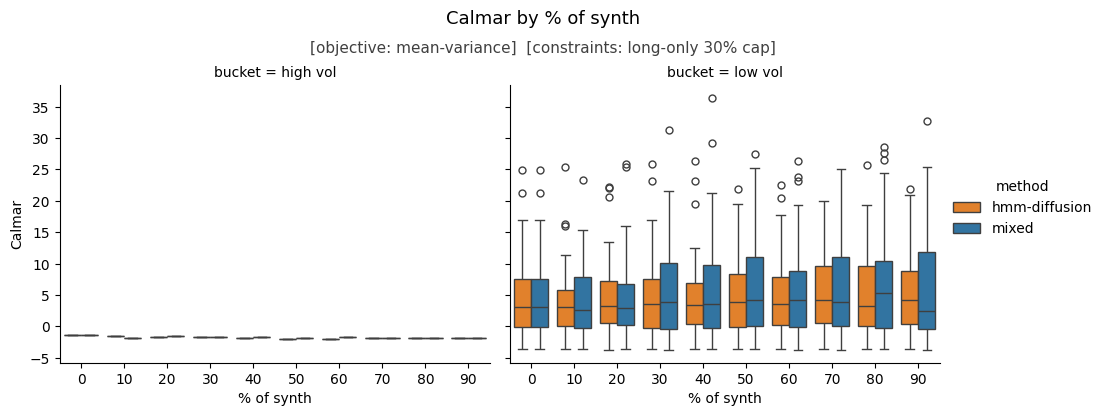

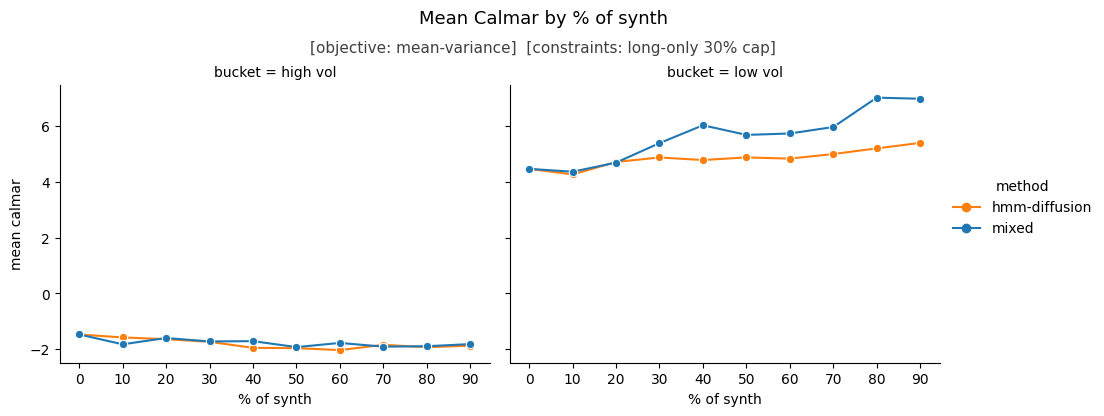

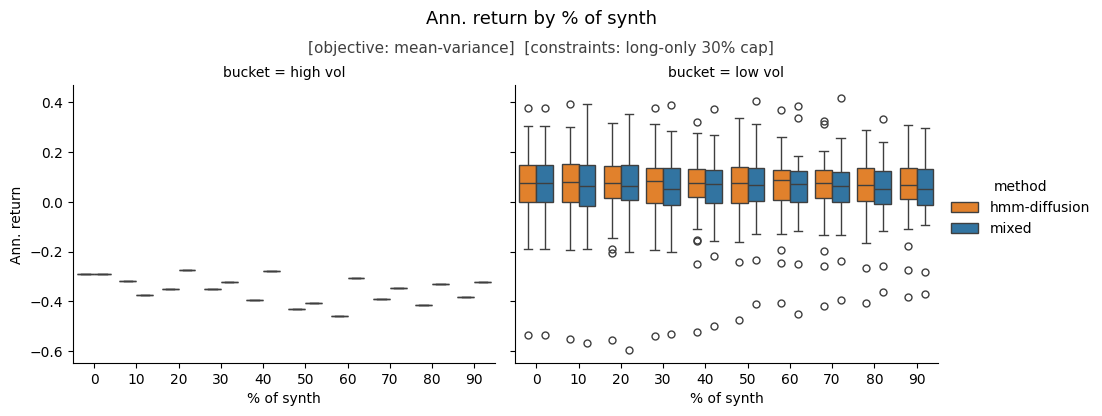

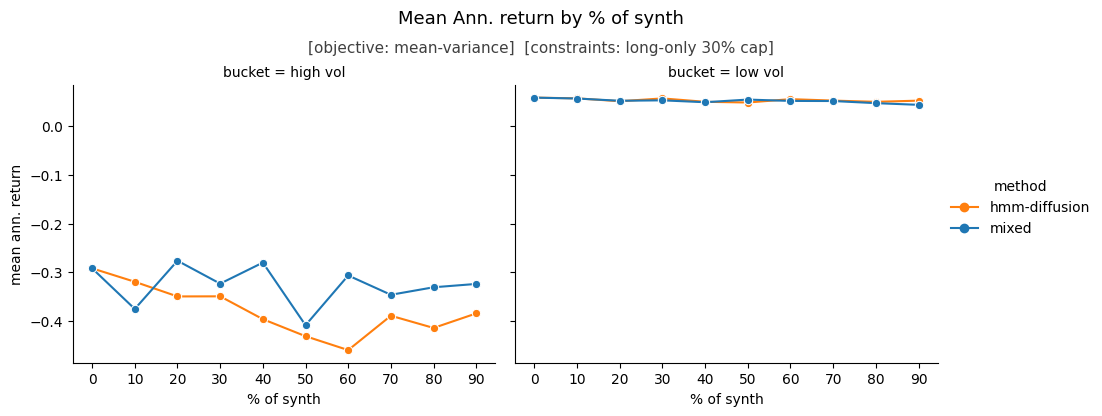

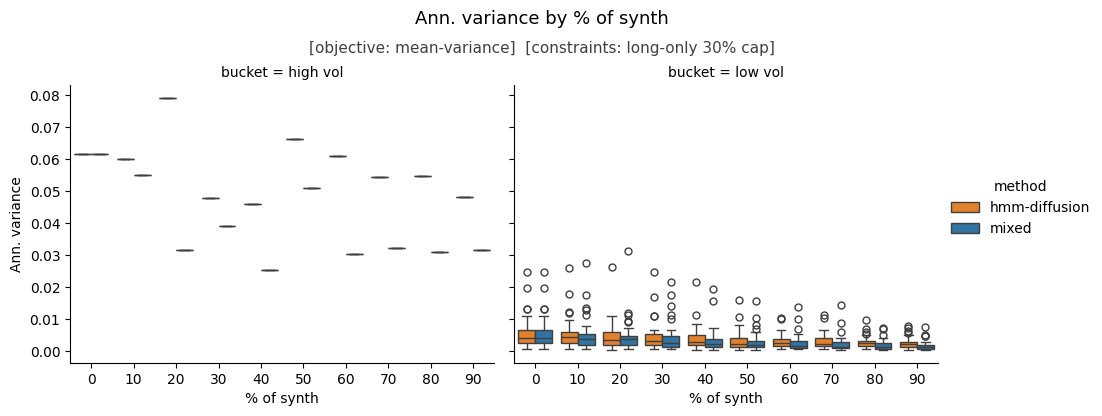

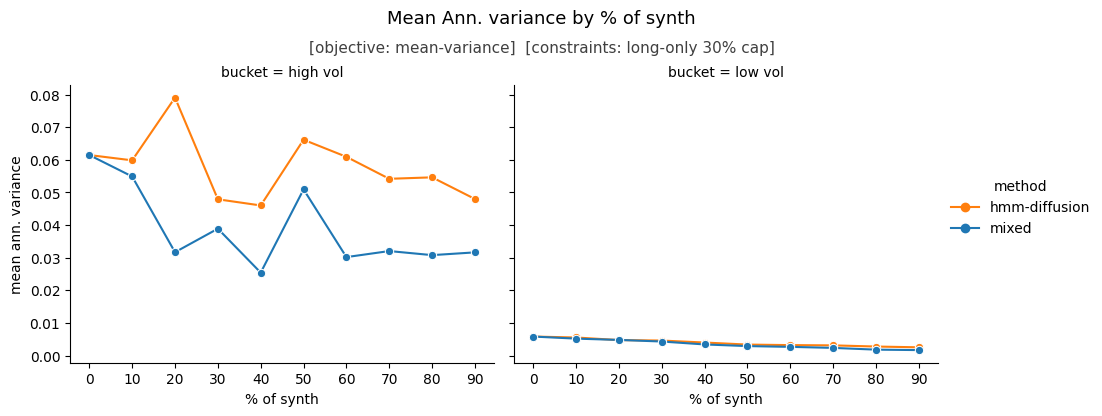

In [11]:
MAX_WEIGHT = 0.30
result_capped = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    mix_mode=MIX_MODE,
)

display(result_capped.summary.sort_values(["bucket", "n_synth", "method"]))
for metric in plots.MVO_WINDOW_METRICS:
    plots.plot_mvo_boxes(
        result_capped.windows,
        metric,
        objective="mean-variance",
        constraint="long-only 30% cap",
    )
    plots.plot_mvo_means(
        result_capped.windows,
        metric,
        objective="mean-variance",
        constraint="long-only 30% cap",
    )


## Long-only 30% cap, max Sharpe

Same mix, holds, seeds, long-only, and 30% name cap as the previous cell. Weights maximize Sharpe (`w ∝ Σ^{-1} μ`, rf = 0) on the row-appended 10-asset matrix, then project onto `w ≥ 0`, `w ≤ 0.30`, `sum w = 1`.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,1,-1.2817,-1.2817,-1.3318,-1.3318,-0.1848,-0.1848,0.0208,0.0208
20,uncondi-diffusion,0,0.0000,high vol,1,-1.2817,-1.2817,-1.3318,-1.3318,-0.1848,-0.1848,0.0208,0.0208
2,hmm-diffusion,10,10.0000,high vol,1,-1.3679,-1.3679,-1.4077,-1.4077,-0.2002,-0.2002,0.0214,0.0214
22,uncondi-diffusion,10,10.0000,high vol,1,-1.5306,-1.5306,-1.5385,-1.5385,-0.2281,-0.2281,0.0222,0.0222
4,hmm-diffusion,20,20.0000,high vol,1,-1.1962,-1.1962,-1.3219,-1.3219,-0.1779,-0.1779,0.0221,0.0221
24,uncondi-diffusion,20,20.0000,high vol,1,-1.4802,-1.4802,-1.4552,-1.4552,-0.1947,-0.1947,0.0173,0.0173
6,hmm-diffusion,30,30.0000,high vol,1,-1.5669,-1.5669,-1.5860,-1.5860,-0.2463,-0.2463,0.0247,0.0247
26,uncondi-diffusion,30,30.0000,high vol,1,-1.5418,-1.5418,-1.5480,-1.5480,-0.2295,-0.2295,0.0222,0.0222
8,hmm-diffusion,40,40.0000,high vol,1,-1.5397,-1.5397,-1.5011,-1.5011,-0.2092,-0.2092,0.0185,0.0185
28,uncondi-diffusion,40,40.0000,high vol,1,-1.7002,-1.7002,-1.6793,-1.6793,-0.2606,-0.2606,0.0235,0.0235


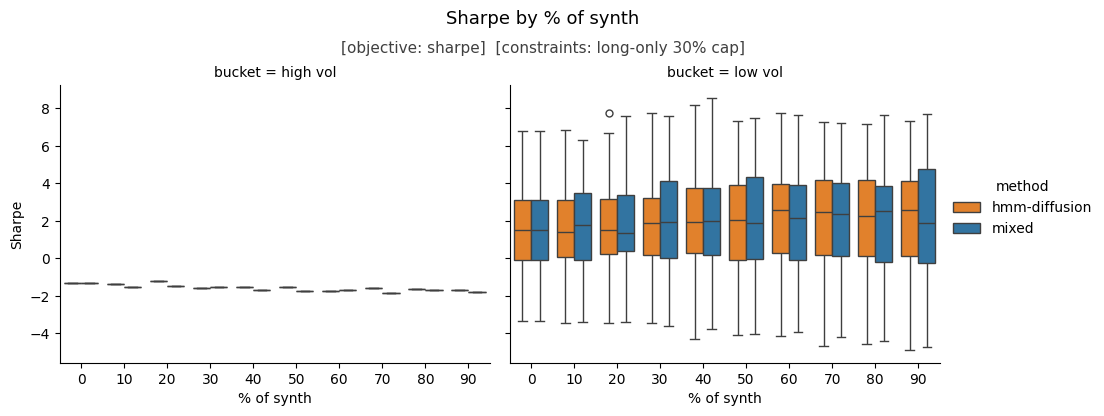

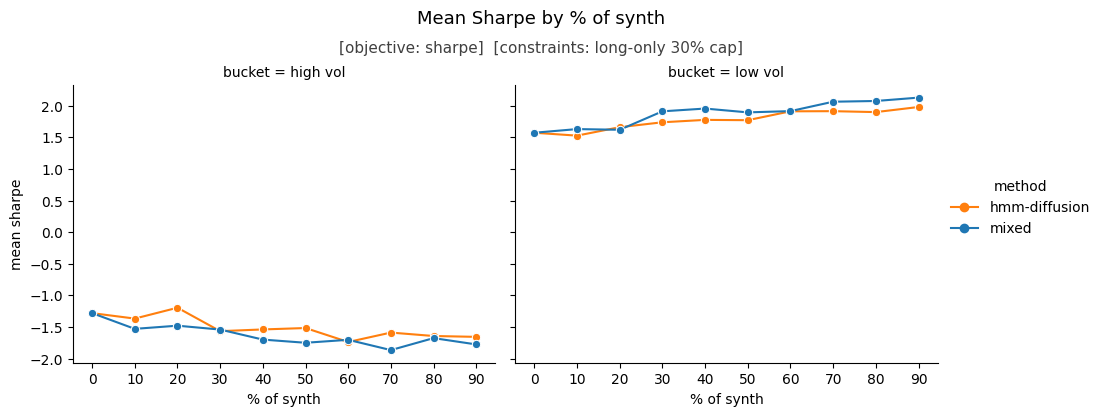

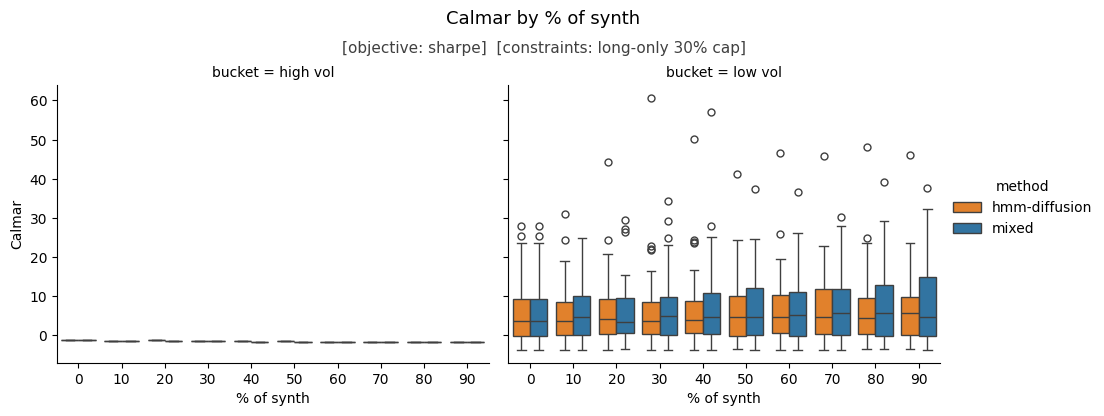

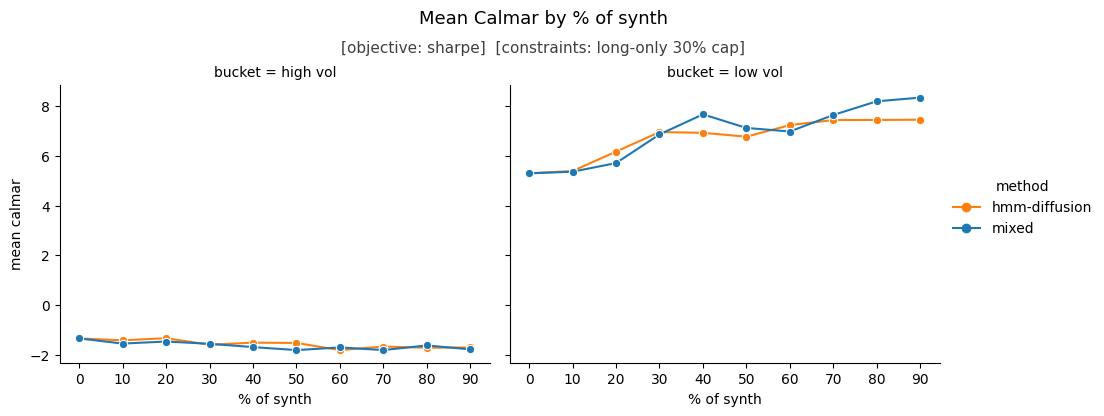

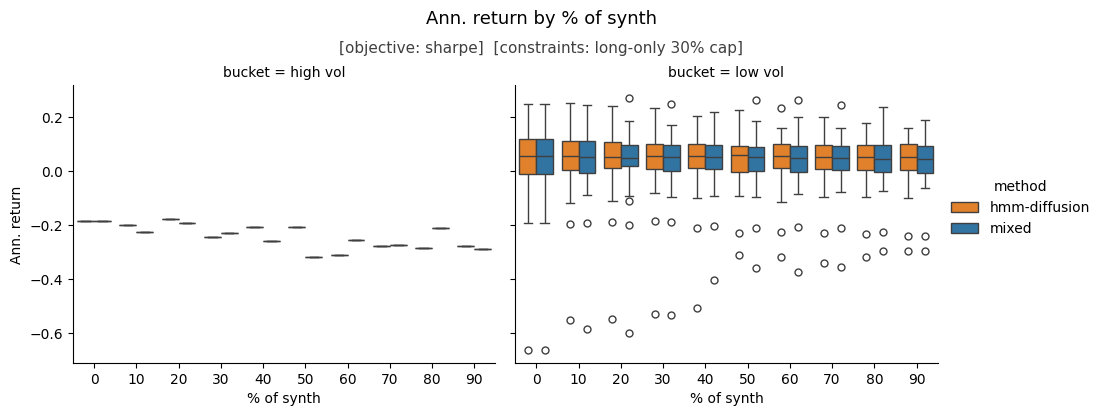

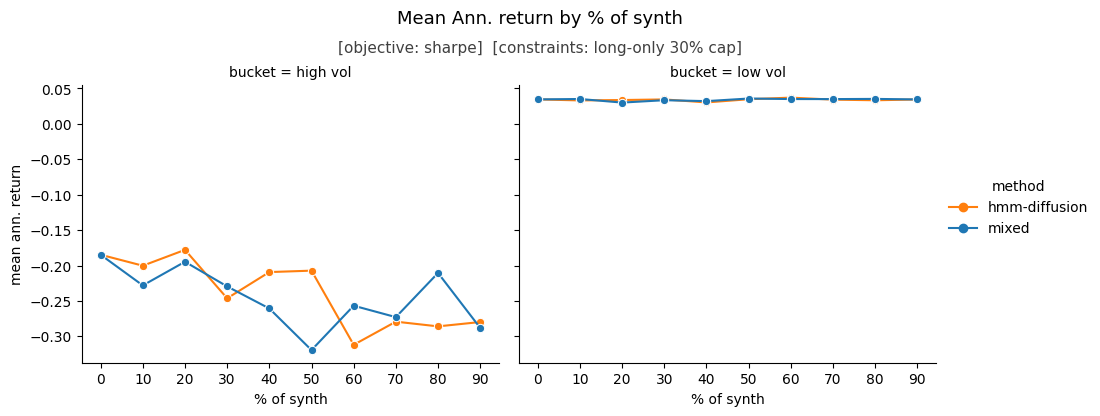

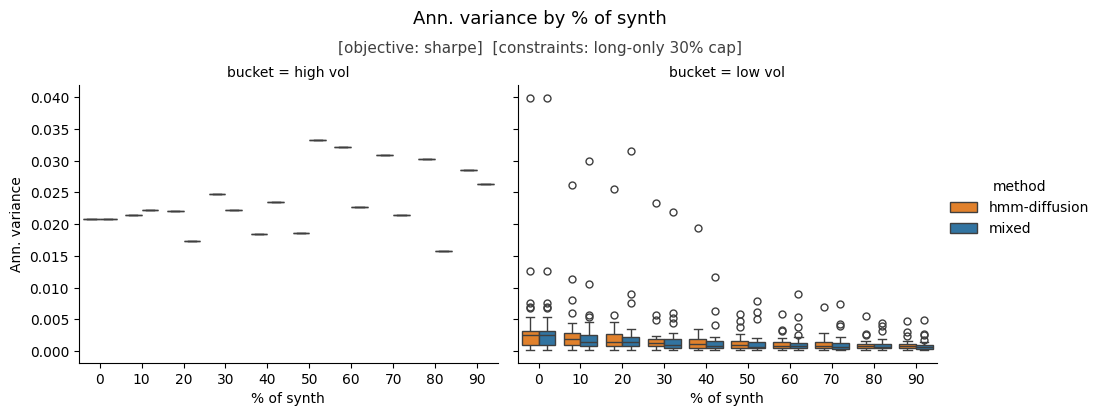

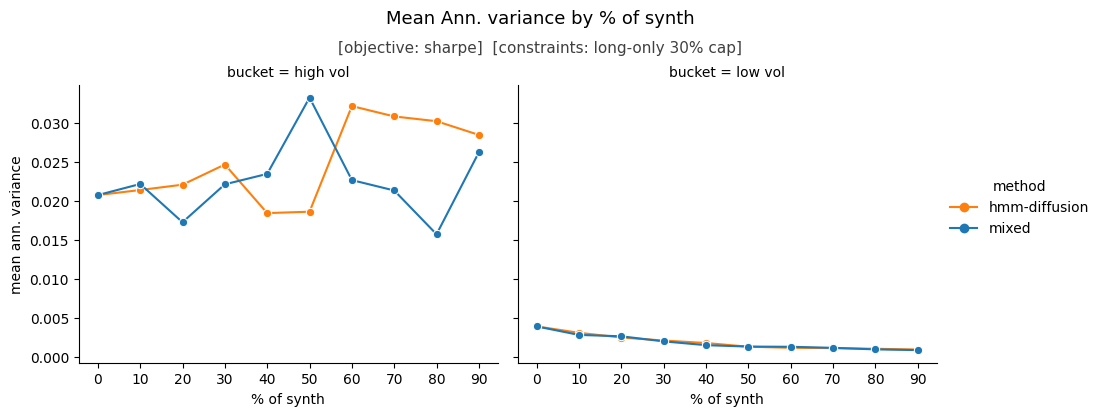

In [12]:
MAX_WEIGHT = 0.30
result_max_sharpe = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_sharpe",
    mix_mode=MIX_MODE,
)

display(result_max_sharpe.summary.sort_values(["bucket", "n_synth", "method"]))
for metric in plots.MVO_WINDOW_METRICS:
    plots.plot_mvo_boxes(
        result_max_sharpe.windows,
        metric,
        objective="sharpe",
        constraint="long-only 30% cap",
    )
    plots.plot_mvo_means(
        result_max_sharpe.windows,
        metric,
        objective="sharpe",
        constraint="long-only 30% cap",
    )


## Long-only 30% cap, min variance

Same mix, holds, seeds, long-only, and 30% name cap. Weights are global minimum variance (`w ∝ Σ^{-1} 1`) on the row-appended 10-asset matrix, then project onto the 30% cap.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,1,-1.6681,-1.6681,-1.7530,-1.7530,-0.2930,-0.2930,0.0309,0.0309
20,uncondi-diffusion,0,0.0000,high vol,1,-1.6681,-1.6681,-1.7530,-1.7530,-0.2930,-0.2930,0.0309,0.0309
2,hmm-diffusion,10,10.0000,high vol,1,-1.6475,-1.6475,-1.7297,-1.7297,-0.2864,-0.2864,0.0302,0.0302
22,uncondi-diffusion,10,10.0000,high vol,1,-1.6820,-1.6820,-1.7989,-1.7989,-0.3180,-0.3180,0.0357,0.0357
4,hmm-diffusion,20,20.0000,high vol,1,-1.6111,-1.6111,-1.7420,-1.7420,-0.2933,-0.2933,0.0331,0.0331
24,uncondi-diffusion,20,20.0000,high vol,1,-1.6858,-1.6858,-1.8673,-1.8673,-0.3535,-0.3535,0.0440,0.0440
6,hmm-diffusion,30,30.0000,high vol,1,-1.6245,-1.6245,-1.7041,-1.7041,-0.2809,-0.2809,0.0299,0.0299
26,uncondi-diffusion,30,30.0000,high vol,1,-1.7152,-1.7152,-1.8094,-1.8094,-0.3139,-0.3139,0.0335,0.0335
8,hmm-diffusion,40,40.0000,high vol,1,-1.6487,-1.6487,-1.7128,-1.7128,-0.2788,-0.2788,0.0286,0.0286
28,uncondi-diffusion,40,40.0000,high vol,1,-1.7263,-1.7263,-1.8527,-1.8527,-0.3350,-0.3350,0.0377,0.0377


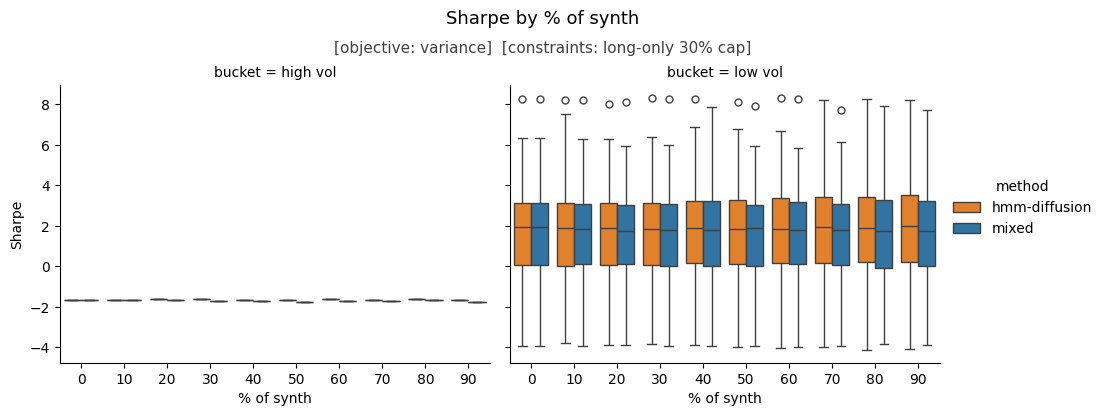

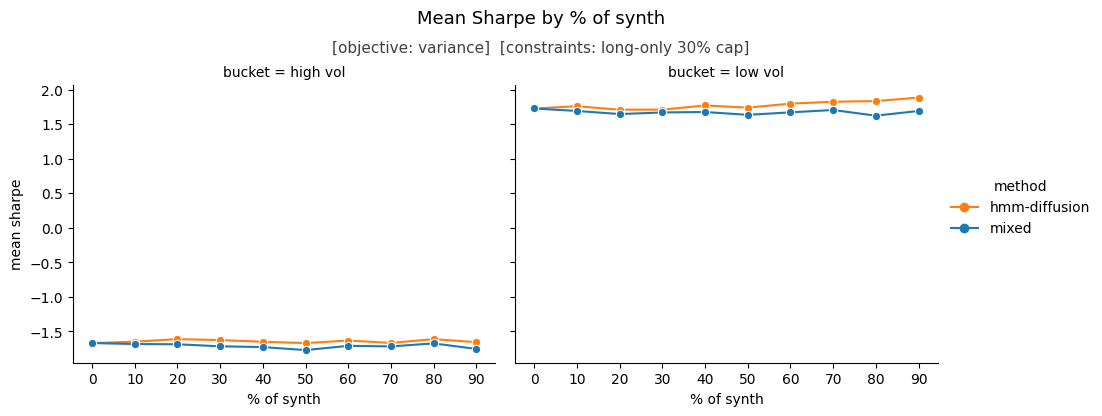

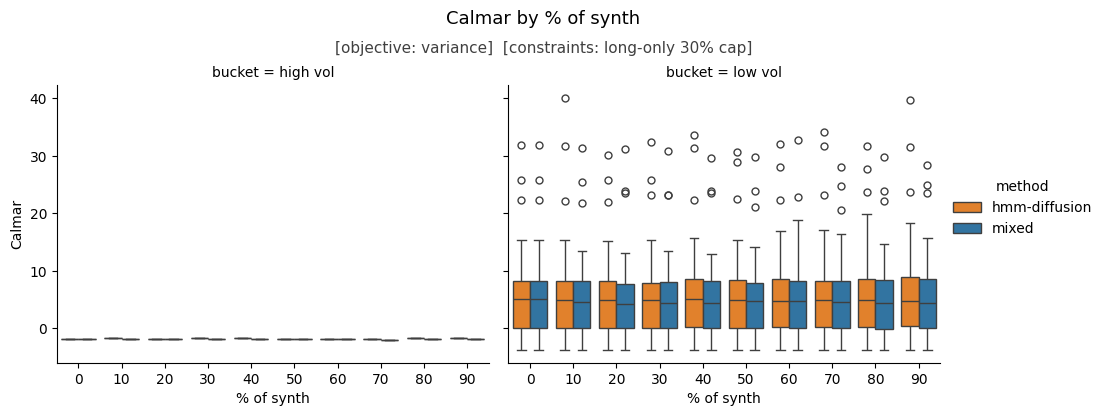

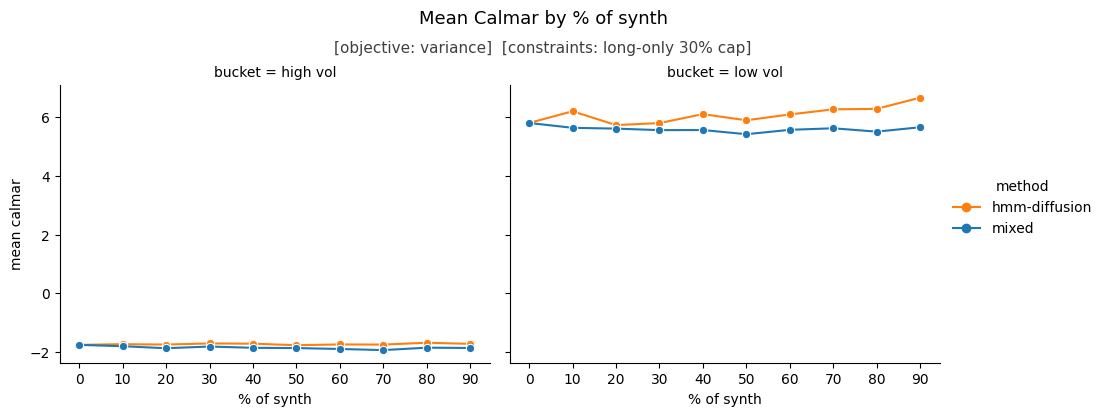

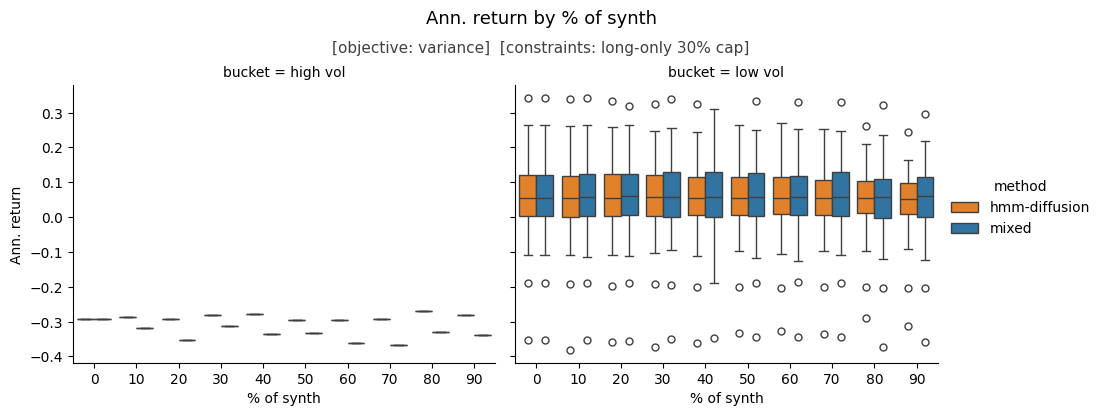

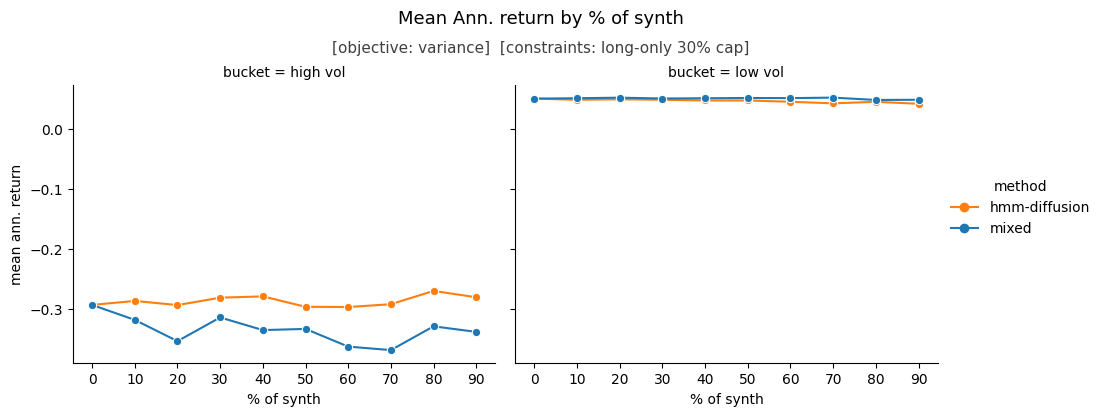

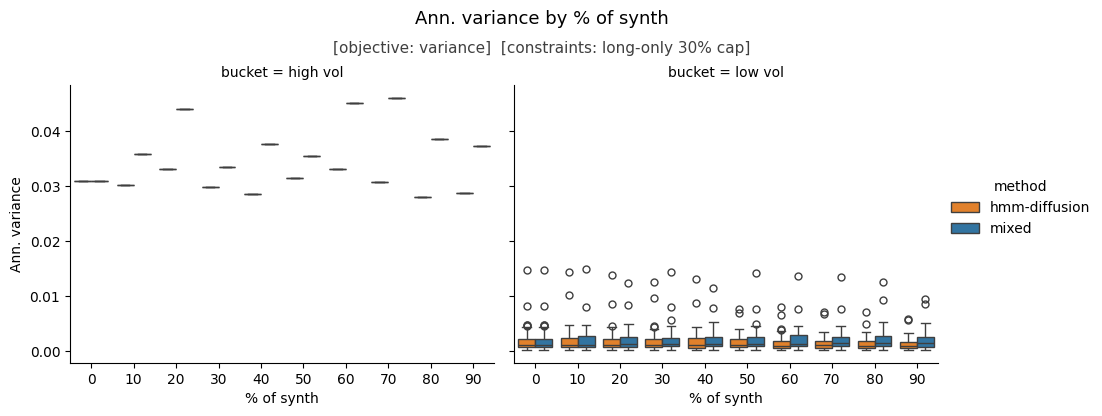

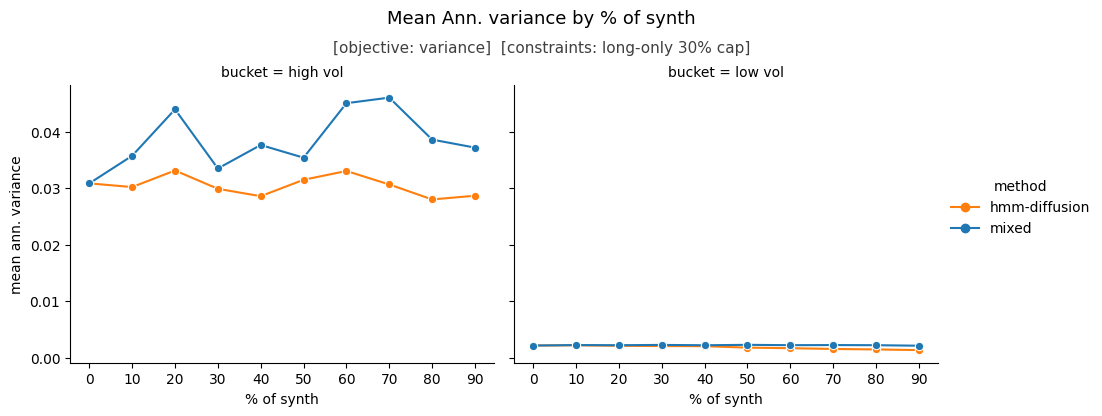

In [13]:
result_min_var = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="min_variance",
    mix_mode=MIX_MODE,
)

display(result_min_var.summary.sort_values(["bucket", "n_synth", "method"]))
for metric in plots.MVO_WINDOW_METRICS:
    plots.plot_mvo_boxes(
        result_min_var.windows,
        metric,
        objective="variance",
        constraint="long-only 30% cap",
    )
    plots.plot_mvo_means(
        result_min_var.windows,
        metric,
        objective="variance",
        constraint="long-only 30% cap",
    )


## Long-only 30% cap, max return

Same mix, holds, seeds, long-only, and 30% name cap. Fill the highest-mean names first: 30% in the best, 30% in the next, and so on, until the weights sum to 1. Means come from the row-appended 10-asset matrix. Covariance is not used.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,1,-1.4634,-1.4634,-2.3190,-2.3190,-0.8725,-0.8725,0.3555,0.3555
20,uncondi-diffusion,0,0.0000,high vol,1,-1.4634,-1.4634,-2.3190,-2.3190,-0.8725,-0.8725,0.3555,0.3555
2,hmm-diffusion,10,10.0000,high vol,1,-1.2778,-1.2778,-2.0111,-2.0111,-0.7724,-0.7724,0.3654,0.3654
22,uncondi-diffusion,10,10.0000,high vol,1,-1.2385,-1.2385,-2.0249,-2.0249,-0.7977,-0.7977,0.4148,0.4148
4,hmm-diffusion,20,20.0000,high vol,1,-1.2385,-1.2385,-2.0249,-2.0249,-0.7977,-0.7977,0.4148,0.4148
24,uncondi-diffusion,20,20.0000,high vol,1,-1.6573,-1.6573,-2.4385,-2.4385,-0.8794,-0.8794,0.2815,0.2815
6,hmm-diffusion,30,30.0000,high vol,1,-1.3568,-1.3568,-2.2285,-2.2285,-0.8646,-0.8646,0.4061,0.4061
26,uncondi-diffusion,30,30.0000,high vol,1,-1.6774,-1.6774,-2.4528,-2.4528,-0.8797,-0.8797,0.2750,0.2750
8,hmm-diffusion,40,40.0000,high vol,1,-1.9476,-1.9476,-2.6642,-2.6642,-0.9971,-0.9971,0.2621,0.2621
28,uncondi-diffusion,40,40.0000,high vol,1,-1.7892,-1.7892,-2.5826,-2.5826,-0.9890,-0.9890,0.3056,0.3056


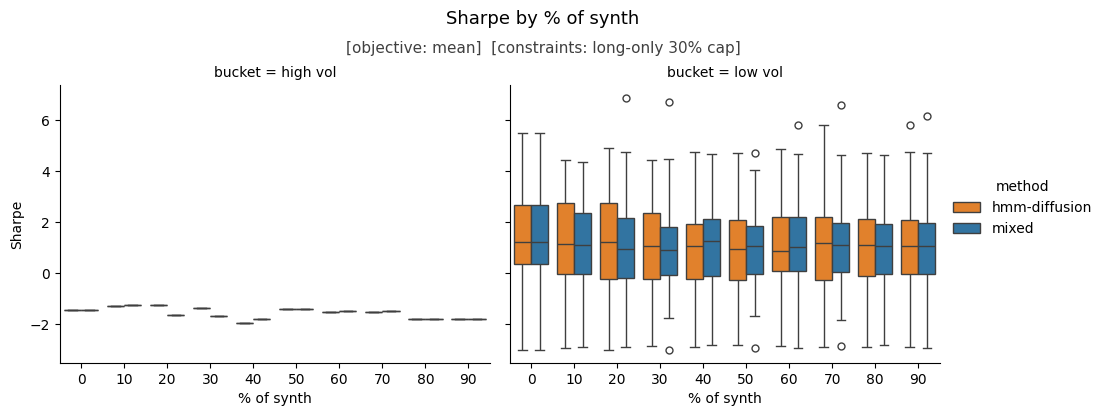

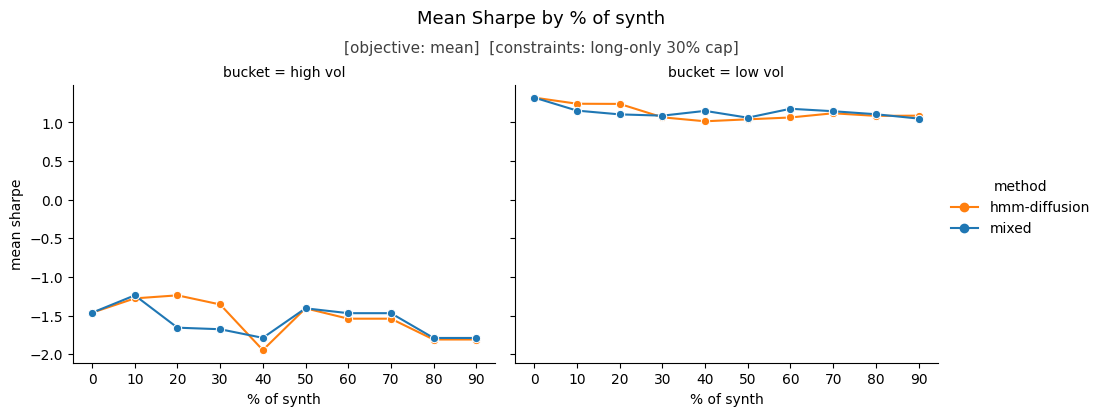

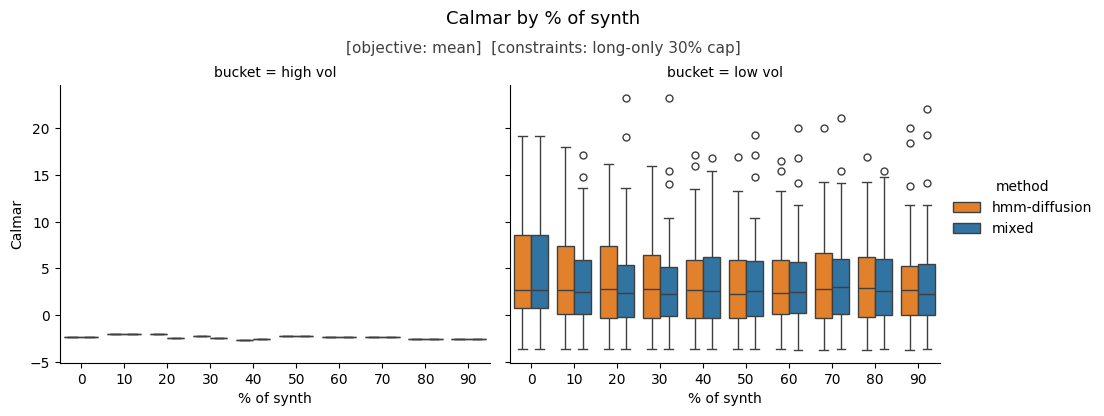

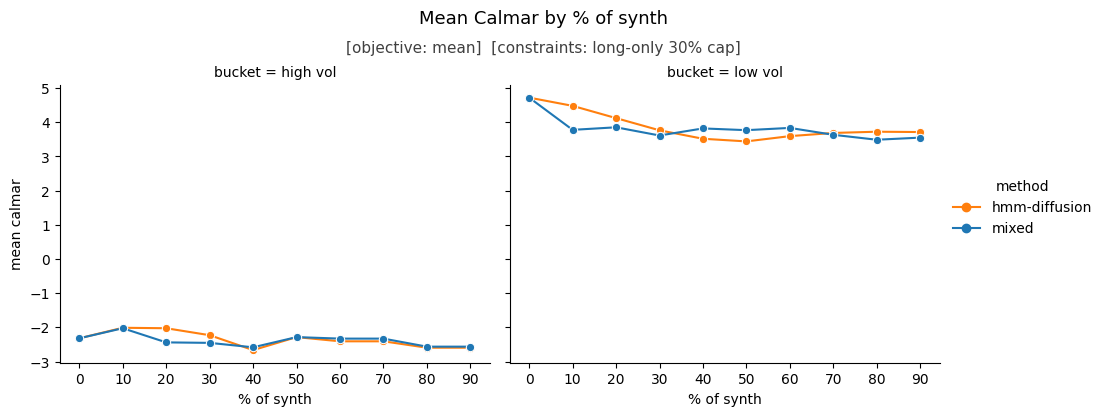

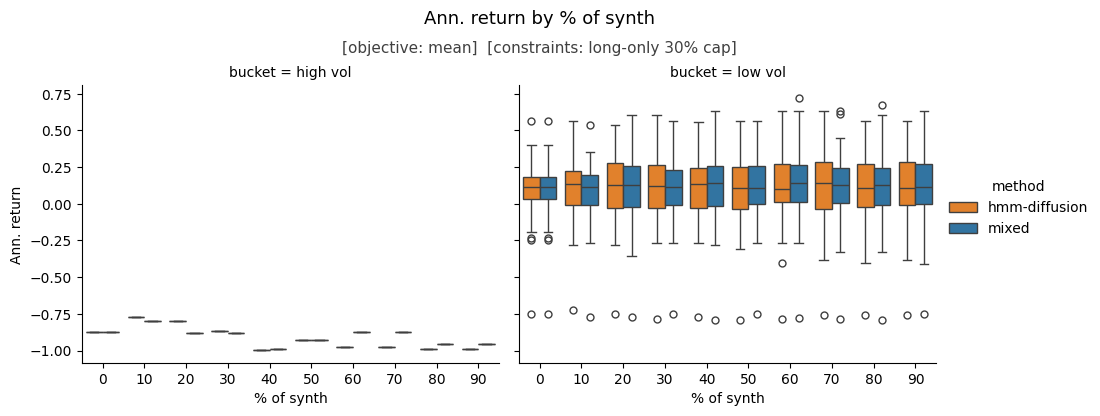

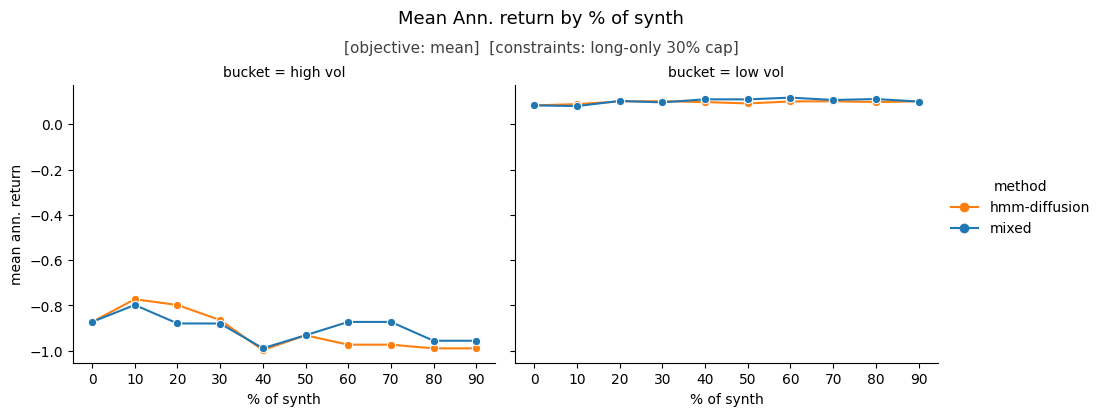

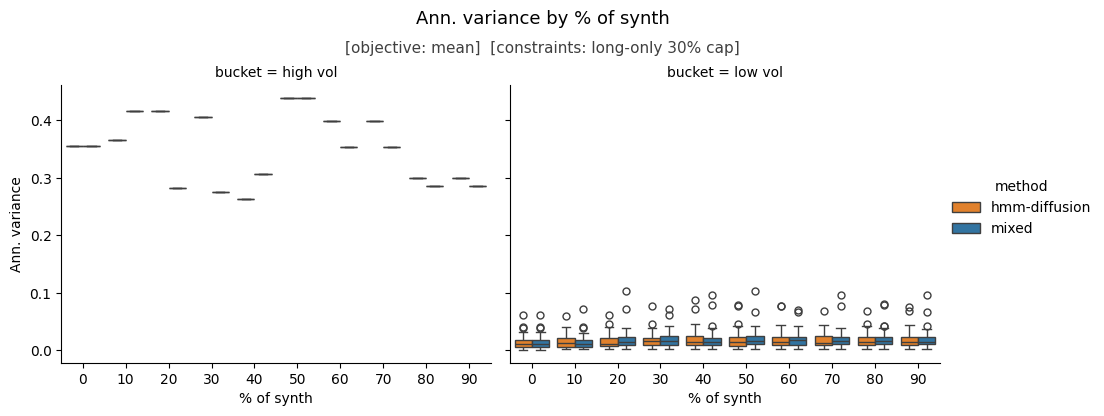

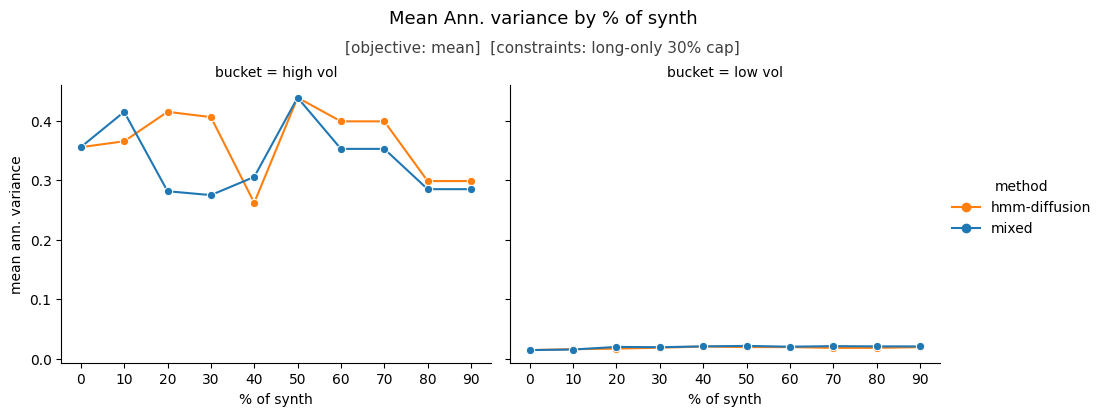

In [14]:
result_max_return = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_return",
    mix_mode=MIX_MODE,
)

display(result_max_return.summary.sort_values(["bucket", "n_synth", "method"]))
for metric in plots.MVO_WINDOW_METRICS:
    plots.plot_mvo_boxes(
        result_max_return.windows,
        metric,
        objective="mean",
        constraint="long-only 30% cap",
    )
    plots.plot_mvo_means(
        result_max_return.windows,
        metric,
        objective="mean",
        constraint="long-only 30% cap",
    )
